# Esercizi - Lezione 3
## Basi di Tensorflow e Keras

Tensorflow e Keras sono tra i framework più usati e versatili.

In [113]:
import tensorflow as tf

with tf.device('CPU:0'):
    a = tf.Variable([[2.0, -3.0, 1.0], [1.0, 5.0, 3.0]]) ## Oggetti storati nella RAM
    b = tf.constant([[1.0, 1.0], [2.0, 2.0], [3.0, 3.0]])

with tf.device('GPU:0'): 
    print(tf.config.list_physical_devices('GPU'))
    c = tf.matmul(a, b) # a e b copiati nella vram e operazioni fatte lì

print(c) # fuori dal blocco GPU, usa la memoria RAM della CPU

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
tf.Tensor(
[[-1. -1.]
 [20. 20.]], shape=(2, 2), dtype=float32)


## Esercizio 1

Simple Multi Layer Perceptron network

In [124]:
import numpy as np

# set seed for reproducibility
tf.random.set_seed(0)

# Input and Output Size of the Multi Layer Perceptron
n_input = 1
n_output = 1

# Number of neurons in each layer
n_hidden_1 = 5
n_hidden_2 = 2


# weights and bias dictionary
weights = {
    'hidden1' : tf.Variable(tf.random.normal((n_input, n_hidden_1))),
    'hidden2' : tf.Variable(tf.random.normal([n_hidden_1, n_hidden_2])),
    'output' : tf.Variable(tf.random.normal([n_hidden_2, n_output]))
}

biases = {
    'bias1' : tf.Variable(tf.random.normal([n_hidden_1])),
    'bias2' : tf.Variable(tf.random.normal([n_hidden_2])),
    'output' : tf.Variable(tf.random.normal([n_output]))
}

# Definisco il mlp
def multilayer_perceptron(x):
    layer1 = tf.sigmoid(tf.add(tf.matmul(x, weights['hidden1']), biases['bias1'])) # equivalente a usare + e @
    layer2 = tf.sigmoid(tf.add(tf.matmul(layer1, weights['hidden2']), biases['bias2'])) 
    out_layer = tf.matmul(layer2, weights['output']) + biases['output']

    return out_layer

x = np.linspace(-2,2,10,dtype=np.float32).reshape(-1,1)
y1 = multilayer_perceptron(x)
print(y1)

tf.Tensor(
[[-2.4766872]
 [-2.5830898]
 [-2.6968765]
 [-2.7944717]
 [-2.863155 ]
 [-2.9048207]
 [-2.9268868]
 [-2.9360034]
 [-2.937006 ]
 [-2.9335566]], shape=(10, 1), dtype=float32)


## Esercizio 2

Modello sequenziale

In [115]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(n_hidden_1, activation="sigmoid"))
model.add(tf.keras.layers.Dense(n_hidden_2, activation="sigmoid"))
model.add(tf.keras.layers.Dense(n_output, activation="linear"))

model.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 5)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [116]:
model.set_weights([weights['hidden1'], biases['bias1'],
                  weights['hidden2'], biases['bias2'],
                  weights['output'], biases['output']])

y2 = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


Vediamo se i risultati tra i due modelli sono compatibili

In [117]:
delta = y2 - y1
delta

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)>

Avremmo anche potuto usare:

In [118]:
if np.allclose(y1, y2):
    print("results match")

results match


## Esercizio 3 

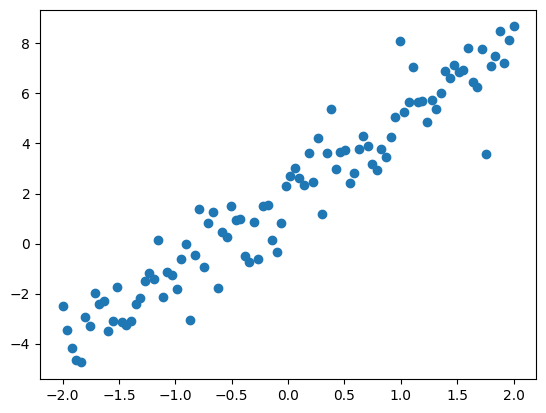

In [119]:
import matplotlib.pyplot as plt

tf.random.set_seed(0)

def f(x):
    return x * 3. + 2.

# Generiamo dei dati
def generate_data(nsize=100):
    x = tf.linspace(-2,2, nsize)
    x = tf.cast(x, tf.float32)

    noise = tf.random.normal(shape=x.shape)

    y = f(x) + noise

    return x,y

x, y = generate_data()

plt.plot(x, y, 'o')

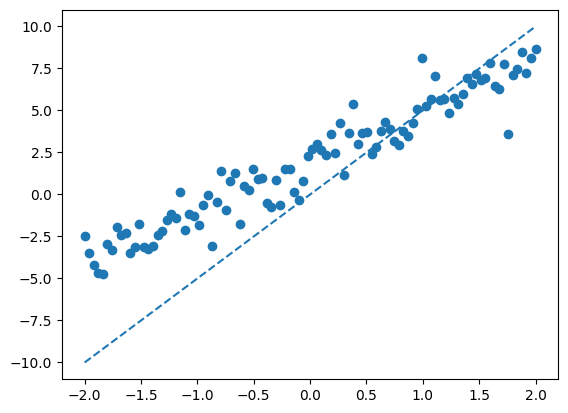

In [120]:
class Modello(tf.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._w = tf.Variable(5.)
        self._b = tf.Variable(0.)
    def __call__(self, x):
        return self._w * x + self._b

model = Modello()
ypred = model(x)

plt.scatter(x, y)
plt.plot(x, ypred, '--') # modello non trainato

In [121]:
# Creo una funzione di loss (MSE)
def loss(target_y, predicted_y):
    return tf.reduce_mean(tf.square(target_y-predicted_y))

current_loss = loss(y, ypred)

f"Untrained Loss: {current_loss}"

'Untrained Loss: 10.20933723449707'

Ora facciamo un fit. Vediamo con un numero di epoche diciamo 10.

Starting training process...
      w = 5.00, b = 0.00, loss = 10.20934

Epoch  0:
     w = 4.46, b = 0.39, loss = 6.30651

Epoch  1:
     w = 4.06, b = 0.70, loss = 4.08812

Epoch  2:
     w = 3.78, b = 0.95, loss = 2.81641

Epoch  3:
     w = 3.57, b = 1.15, loss = 2.08097

Epoch  4:
     w = 3.42, b = 1.31, loss = 1.65187

Epoch  5:
     w = 3.30, b = 1.44, loss = 1.39928

Epoch  6:
     w = 3.22, b = 1.54, loss = 1.24929

Epoch  7:
     w = 3.16, b = 1.62, loss = 1.15949

Epoch  8:
     w = 3.12, b = 1.69, loss = 1.10529

Epoch  9:
     w = 3.09, b = 1.74, loss = 1.07235
Trained Loss: 1.0723453760147095


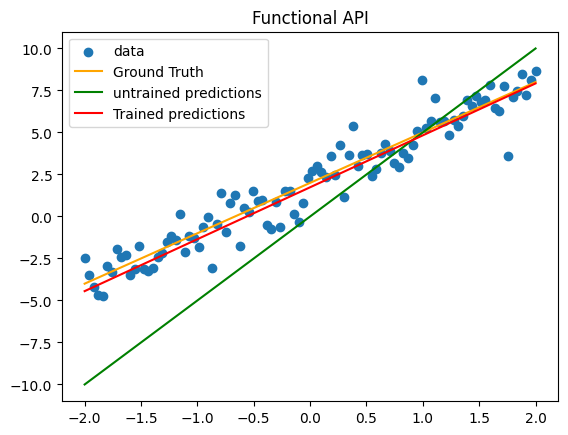

In [122]:
print(f"Starting training process...")

epochs = range(10)

# Mostra lo stato del modello: pesi bias e loss 
def report(model, loss):
    return f"w = {model._w.numpy():1.2f}, b = {model._b.numpy():1.2f}, loss = {loss:2.5f}"


print("     ", report(model, current_loss)) # Qui current loss ti stampa il valore che aveva nella cella prima

# Definisco una funzione di training
def train(model, x, y, learning_rate):
    with tf.GradientTape() as t:
        current_loss = loss(y, model(x))

        dw, db = t.gradient(current_loss, [model._w, model._b])

        model._w.assign_sub(learning_rate * dw)
        model._b.assign_sub(learning_rate * db)


# Definisco un training loop
def training_loop(model, x, y, epochs):
    weights = []
    biases = []

    for epoch in epochs:
        train(model, x, y, learning_rate=.1)
        weights.append(model._w.numpy())
        biases.append(model._b.numpy())

        c_loss = loss(y, model(x))

        print(f"\nEpoch {epoch:2d}:")
        print(f"    ", report(model, c_loss))

    return weights, biases

weights, biases = training_loop(model, x, y, epochs)

print(f"Trained Loss: {loss(model(x), y)}")


plt.scatter(x, y, label='data')
plt.plot(x, f(x), "orange", label="Ground Truth")
plt.plot(x, ypred, "green", label="untrained predictions")
plt.plot(x, model(x), "red", label="Trained predictions")
plt.title("Functional API")
plt.legend()
plt.show()

Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - loss: 10.2093
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 6.3065
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 4.0881
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.8164
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2.0810
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.6519
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.3993
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.2493
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1595
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1053


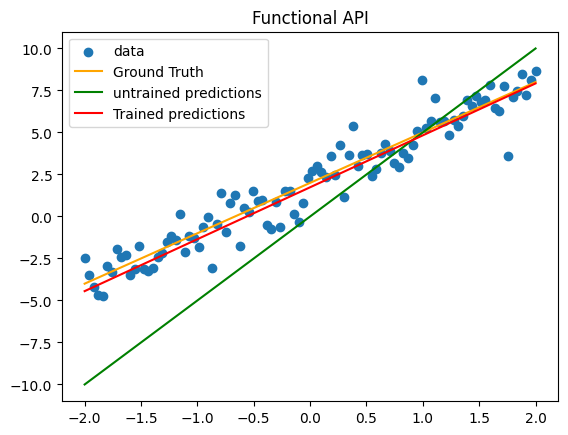

In [123]:
# Ora usaiamo keras

inputs = tf.keras.Input(shape=(1,))
output = tf.keras.layers.Dense(
    units=1,
    use_bias=True,
    kernel_initializer=tf.keras.initializers.Constant(5.),
    bias_initializer=tf.keras.initializers.Constant(0.))(inputs)
    
keras_model = tf.keras.Model(inputs=inputs, outputs=output)
keras_model.summary()
keras_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=.1), 
                    loss = tf.keras.losses.MeanSquaredError)

keras_model.fit(x, y, epochs=10, batch_size=len(x))

plt.scatter(x, y, label='data')
plt.plot(x, f(x), "orange", label="Ground Truth")
plt.plot(x, ypred, "green", label="untrained predictions")
plt.plot(x, keras_model(x), "red", label="Trained predictions")
plt.title("Functional API")
plt.legend()
plt.show()
